# Helmholtz equation

This notebook demonstrates a differentiable spectral solver for reaction–diffusion
equations on the sphere, built on `torch-harmonics`. The solver supports two PDEs:

- **Allen–Cahn**: $\partial_t u = \epsilon\,\Delta u + u - u^3$
- **Ginzburg–Landau**: $\partial_t u = \epsilon\,\Delta u + u - (1+i\beta)\,|u|^2 u$

Time integration is performed in spectral space using third-order Adams–Bashforth,
and the results are saved as an animated GIF.

## Setup

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from math import ceil
from tqdm.auto import tqdm

from torch_harmonics.examples import SphereSolver

cmap='twilight_shifted'

/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Solver configuration

The `SphereSolver` class provides the spectral infrastructure: it precomputes the
SHT operators, quadrature weights, and the hyperdiffusion filter. We choose a
resolution of 128 latitudes, a diffusion coefficient of 0.01, and integrate for
10 time units with $\Delta t = 0.001$.

In [3]:
# initialize parameters:
nlat = 128
nlon = 2*nlat
lmax = ceil(nlon/4)
mmax = lmax

# timestepping
dt = 0.001
maxiter = int(10 / dt)

# initialize solver class
solver = SphereSolver(nlat, nlon, dt, lmax=lmax, mmax=mmax, coeff=0.01).to(device)

lons = solver.lons
lats = solver.lats

jj, ii = torch.triu_indices(lmax, mmax)


## Initial condition

We generate a random initial condition in spectral space using `solver.randspec()`.
This produces a band-limited random field on the sphere:

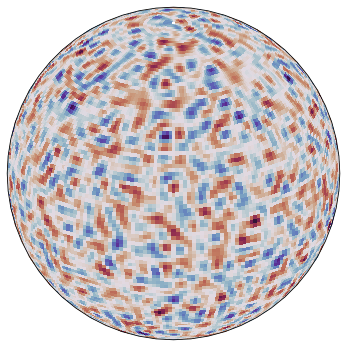

In [4]:
uspec0 = solver.randspec()
fig = plt.figure(figsize=(8, 6), dpi=72)
solver.plot_specdata(uspec0, fig, cmap=cmap)
plt.show()

## Time integration

We integrate the PDE using third-order Adams–Bashforth. Every 20 steps, the current
state is rendered into the animation. Since we only need the forward pass, the loop
runs inside `torch.no_grad()` to save memory.

Helmholtz integration: 100%|██████████| 10001/10001 [00:23<00:00, 417.34it/s, t=10.00]


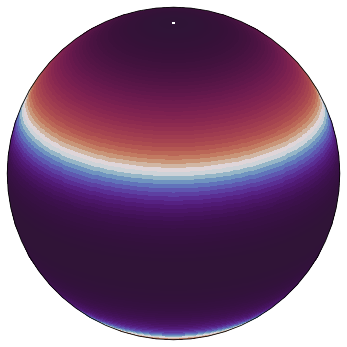

In [5]:
import os
os.makedirs("plots", exist_ok=True)

dudtspec = torch.zeros(3, solver.lmax, solver.mmax, dtype=torch.complex128, device=device)
nnew = 0
nnow = 1
nold = 2

uspec = uspec0.clone().to(device)
# pde = 'allen-cahn'
pde = 'ginzburg-landau'


# prepare figure for animation
fig = plt.figure(figsize=(8, 6), dpi=72)
moviewriter = animation.writers['pillow'](fps=20)
moviewriter.setup(fig, f'./plots/{pde}.gif', dpi=72)


pbar = tqdm(range(maxiter+1), desc="Helmholtz integration")
with torch.no_grad():
    for iter in pbar:
        t = iter*dt

        if iter % 20 == 0:
            pbar.set_postfix_str(f"t={t:.2f}")
            plt.clf()
            solver.plot_specdata(uspec, fig, cmap=cmap)
            plt.draw()
            moviewriter.grab_frame()

        dudtspec[nnew] = solver.dudtspec(uspec, pde=pde)
        
        # forward euler, then 2nd-order adams-bashforth time steps to start.
        if iter == 0:
            dudtspec[nnow] = dudtspec[nnew]
            dudtspec[nold] = dudtspec[nnew]
        elif iter == 1:
            dudtspec[nold] = dudtspec[nnew]

        uspec = uspec + solver.dt*( (23./12.) * dudtspec[nnew] - (16./12.) * dudtspec[nnow] + (5./12.) * dudtspec[nold] )

        # cycle through the indices
        nsav1 = nnew
        nsav2 = nnow
        nnew = nold
        nnow = nsav1
        nold = nsav2


moviewriter.finish()